# Steinmetz ISI-shuffle control

This notebook reproduces SI Fig. S2(B) from the four Steinmetz sessions. 

For every unit, the interspike intervals are randomly permuted while preserving the spike count and marginal ISI distribution. The complete clustering workflow is then repeated 50 times per session.

A shuffled realization is counted as a false positive when it satisfies the full prespecified Early/Mid/Late SPN pattern used in the original analysis.

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Reproducibility settings

Each session uses the matching seed recorded in `data/source/steinmetz/session_manifest.csv`. The ISI shuffle uses a separate keyed random stream for every session, repetition, and unit, so it does not alter the contrast-matching trial selection.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spn_figures.config import DERIVED, FIGURES, SOURCE
from spn_figures.io import read_csv, save_figure, write_csv
from spn_figures.isi import (
    STEINMETZ_SESSION_ORDER,
    plot_isi_false_positive_rates,
    run_steinmetz_isi_shuffle_session,
    summarize_isi_shuffle_runs,
)

N_SHUFFLES = 50
source_dir = SOURCE / "steinmetz"
out_dir = DERIVED / "steinmetz"
out_dir.mkdir(parents=True, exist_ok=True)

manifest = read_csv(source_dir / "session_manifest.csv")
manifest = (
    manifest.set_index("session")
    .reindex(STEINMETZ_SESSION_ORDER)
    .reset_index()
)

print(f"Loaded {len(manifest)} Steinmetz sessions; {N_SHUFFLES} shuffles per session.")

Loaded 4 Steinmetz sessions; 50 shuffles per session.


## Run the four session controls

Pipeline failures are retained as `pattern_pass = False`.

In [6]:
session_runs = []

for row in manifest.itertuples(index=False):
    print(f"Running {row.session} ...")
    session_runs.append(
        run_steinmetz_isi_shuffle_session(
            source_dir / row.folder,
            session_name=row.session,
            matching_seed=int(row.matching_seed),
            premove_gap_s=float(row.premove_gap_s),
            n_shuffles=N_SHUFFLES,
        )
    )

runs = pd.concat(session_runs, ignore_index=True)
summary = summarize_isi_shuffle_runs(runs)
summary = (
    summary.set_index("session")
    .reindex(STEINMETZ_SESSION_ORDER)
    .reset_index()
)

write_csv(runs, out_dir / "isi_shuffle_runs.csv")
write_csv(summary, out_dir / "isi_shuffle_summary.csv")
summary

Running Hench_2017-06-18 ...
Running Lederberg_2017-12-11 ...
Running Radnitz_2017-01-12 ...
Running Richards_2017-11-01 ...


,session,matching_seed,n_shuffles,n_pipeline_success,false_positive_count,false_positive_rate
0,Hench_2017-06-18,2,50,50,2,0.04
1,Lederberg_2017-12-11,4,50,45,0,0.00
2,Radnitz_2017-01-12,5,50,48,0,0.00
3,Richards_2017-11-01,27,50,50,3,0.06


## SI Fig. S2(B)

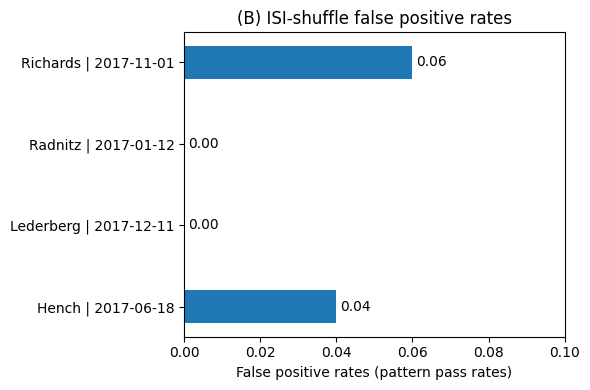

In [7]:
fig, ax = plot_isi_false_positive_rates(summary)
save_figure(fig, FIGURES / "supporting" / "FigS2B_isi_shuffle_false_positive_rates")
plt.show()